# Stage 13 — Connectivity v2: watercourses, slope, and D8 routing

**Question:** does adding mapped watercourses, slope, and (at Mole Creek) D8 upstream flow-routing to the connectivity score change the risk map?

The frozen connectivity score is the highest of three signals (autogenic exposure, proximal catchment, distal catchment; Stage 3). Version 2 adds three things:

1. **Watercourse signal.** Natural watercourses from the LIST hydrolines are buffered by 50 m and scored by stream size (major stream or river 3, stream-sized tributary 2, minor tributary 1). A karst cell near a mapped stream takes at least that score. This works at cell level, so only the karst next to a stream is raised.
2. **Slope factor.** The proximal and distal catchment signals are multiplied by a factor from 0.5 to 1 based on the polygon's mean slope (0.5 on flat ground, 1 at 15 degrees or steeper), because steeper catchments deliver runoff more readily. Exposed, covered and interstratal karst are not slope-scaled. The direction of the slope effect is an assumption (an earlier sensitivity check, formerly Stage 12, showed the opposite direction gives a similar pattern).
3. **D8 upstream-routing signal (Mole Creek only, new).** From the `connectivity-hydlines` branch: WhiteboxTools D8 flow-routing from every source cell to each karst target polygon, classified into Jenks natural-breaks classes. It is uncorrelated with the slope factor (so it is not expected to double-count the same information), but currently only covers the 66 "core" Mole Creek target polygons, not the statewide karst.

Both the 50 m buffer, the stream-size scores and the 15 degree reference are judgements.

The DEM flow-accumulation channel comparison that used to be in Stage 3 is not used here (it has been removed from Stage 3 -- see README.md -- and superseded by the D8 routing work above). Risk is recomputed as the frozen risk multiplied by (connectivity v2 / connectivity v1), which leaves susceptibility and pressure exactly as in the frozen method. Slope needs care. The frozen risk carries the top-level slope multiplier (Stage 6), so the two variants that put slope inside connectivity ("slope only" and "slope + watercourse") drop that multiplier, while the others keep it. Their correlations with the frozen risk therefore mix two things: the change to connectivity, and the different place where slope enters. The "watercourse only" row keeps the same slope treatment as the frozen method, so it isolates the connectivity effect. Results are for the Mole Creek karst only (slope + watercourse, and slope + watercourse + D8), then statewide at 100 m (slope + watercourse only, since the D8 signal is not yet available statewide).


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_v2, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask)
from hydro import load_watercourses, score_watercourses, watercourse_raster, mean_slope_by_polygon, slope_degrees, slope_risk_multiplier
from mapping import add_attribution, add_basemap, finish_map, raster_extent

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

# Variants whose connectivity score already folds in slope (via add_connectivity_v2's
# per-polygon mean-slope scoring) skip the top-level slope factor below, so slope is
# never counted twice; variants without their own slope signal still get it, to stay
# comparable with the frozen baseline (which always carries the top-level factor).
SLOPE_IN_CONNECTIVITY = {"slope only", "slope + watercourse"}

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

def variants(karst, conn_v1, conn_slope_poly, wc_cell, intensity):
    """Connectivity rasters: frozen, slope only, watercourse only, both."""
    on_karst = intensity > 0
    return {
        "frozen": conn_v1,
        "slope only": conn_slope_poly,
        "watercourse only": np.where(on_karst, np.maximum(conn_v1, wc_cell), conn_v1),
        "slope + watercourse": np.where(on_karst, np.maximum(conn_slope_poly, wc_cell), conn_slope_poly),
    }

## 13.1 Watercourses

The natural watercourses (LIST `HYDLNTY1 = Watercourse`) for all of Tasmania are read from the shared `watercourses_tas_EPSG7855.gpkg` in `Output_data`. If that file is missing, they are rebuilt from the 29 council hydroline files (about 15 minutes) and saved under the same name.

In [2]:
karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)

shared = outpath / "watercourses_tas_EPSG7855.gpkg"
if shared.exists():
    wc = gpd.read_file(shared)
else:
    tas = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
    wc = load_watercourses(inpath / "Hydline", tuple(tas.total_bounds))
    wc.to_file(shared, driver="GPKG")
wc = score_watercourses(wc[wc["HYDLNTY1"] == "Watercourse"] if "HYDLNTY1" in wc.columns else wc)
print(f"Natural watercourses statewide: {len(wc)}")
print(wc["HYD_CLASS"].value_counts().to_string())

Natural watercourses statewide: 552028
HYD_CLASS
Minor Tributary    213226
Tributary          162122
Minor Stream        91855
Stream              49745
Major Stream        23134
Minor River          7578
River                2998
Major River          1312
N/A                    55


## 13.2 Mole Creek (25 m)

In [3]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    conn_v1 = src.read(1).astype(float)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape; cell = abs(src.transform.a)
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    risk_base = src.read(1).astype(float); rnodata = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]
risk_base = np.where(valid & (risk_base != rnodata), risk_base, np.nan)

slope = slope_degrees(dem, dem_nodata, cell)
add_connectivity_v2(karst_mc, mean_slope_by_polygon(karst_mc, slope, transform))
conn_slope_poly = rasterize_max(karst_mc, "connectivity_v2", shape, transform, fill=0, dtype="float32").astype(float)
mc_bounds = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").total_bounds
wc_mc = wc.cx[mc_bounds[0]:mc_bounds[2], mc_bounds[1]:mc_bounds[3]]
wc_cell = watercourse_raster(wc_mc, shape, transform).astype(float)

conns = variants(karst_mc, conn_v1, conn_slope_poly, wc_cell, intensity)
print(f"Karst cells within 50 m of a mapped watercourse: {(wc_cell[valid] > 0).mean() * 100:.1f}%")
print(f"Mean slope factor on proximal-catchment polygons: {karst_mc.loc[karst_mc['proximal_score'] > 0, 'slope_factor'].mean():.2f} (1 = no reduction)")

# risk_base already carries the top-level slope factor (Stage 6, frozen). Back it out
# before rescaling by the connectivity ratio, then only reapply it for variants whose
# connectivity does NOT already encode slope -- otherwise slope would count twice for
# "slope only" and "slope + watercourse".
top_level_slope_factor = slope_risk_multiplier(slope)
risk_base_noslope = risk_base / top_level_slope_factor

rows = []
risks_mc = {}
for name, c in conns.items():
    ratio = np.where(conn_v1 > 0, c / np.where(conn_v1 > 0, conn_v1, 1), 1.0)
    risk = risk_base_noslope * ratio
    if name not in SLOPE_IN_CONNECTIVITY:
        risk = risk * top_level_slope_factor
    risks_mc[name] = risk
    rows.append({"variant": name,
                 "mean connectivity": round(np.nanmean(c[valid]), 3),
                 "cells changed %": round((c[valid] != conn_v1[valid]).mean() * 100, 1),
                 "r vs frozen risk": round(corr_nonzero(risk_base, risk, valid), 3),
                 "mean risk": round(np.nanmean(risk[valid]), 4)})
print(pd.DataFrame(rows).to_string(index=False))

table = named_ranking(risk_base, karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk", "n_px"]].rename(columns={"mean_risk": "frozen"})
for name in ["slope only", "watercourse only", "slope + watercourse"]:
    table[name] = named_ranking(risks_mc[name], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.round(3).to_string())

Karst cells within 50 m of a mapped watercourse: 15.1%
Mean slope factor on proximal-catchment polygons: 0.80 (1 = no reduction)


            variant  mean connectivity  cells changed %  r vs frozen risk  mean risk
             frozen              2.387              0.0             1.000     0.1950
         slope only              2.320              8.7             0.860     0.3198
   watercourse only              2.411              2.4             0.991     0.1967
slope + watercourse              2.344             11.1             0.831     0.3231



Mean risk by Mole Creek area:
                              frozen    n_px  slope only  watercourse only  slope + watercourse
KNAME                                                                                          
Mole Creek  (Chudleigh Hill)   0.268     214       0.484             0.268                0.484
Mole Creek                     0.202  388179       0.331             0.203                0.334
Meander - Western Creek        0.089   24111       0.143             0.089                0.143


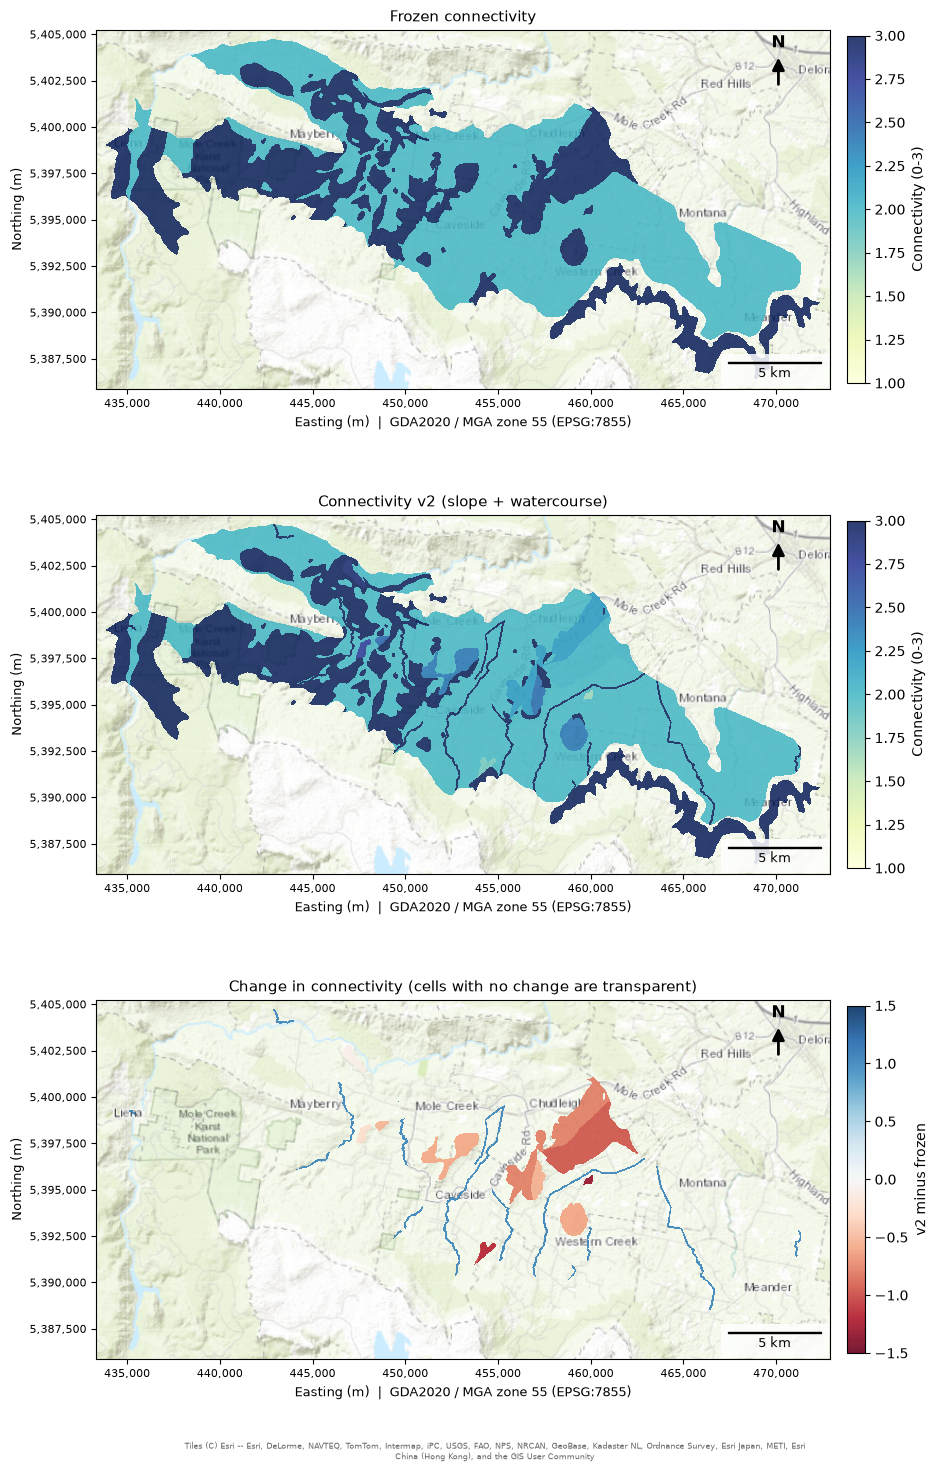

In [4]:
bounds = tuple(karst_only.total_bounds)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
shown = {"Frozen connectivity": conns["frozen"], "Connectivity v2 (slope + watercourse)": conns["slope + watercourse"]}
for ax, (title, arr) in zip(axes[:2], shown.items()):
    add_basemap(ax, bounds, margin=500, zoom=11)
    im = ax.imshow(np.ma.masked_where(~valid, arr), cmap="YlGnBu", vmin=1, vmax=3, alpha=0.85,
                   interpolation="nearest", extent=raster_extent(transform, shape), zorder=2)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Connectivity (0-3)")
    ax.set_title(title, fontsize=11); finish_map(ax)
ax = axes[2]
diff = conns["slope + watercourse"] - conns["frozen"]
add_basemap(ax, bounds, margin=500, zoom=11)
im = ax.imshow(np.ma.masked_where(~valid | (np.abs(diff) < 1e-9), diff), cmap="RdBu", vmin=-1.5, vmax=1.5, alpha=0.9,
               interpolation="nearest", extent=raster_extent(transform, shape), zorder=2)
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="v2 minus frozen")
ax.set_title("Change in connectivity (cells with no change are transparent)", fontsize=11); finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()

## 13.2b Adding Rachel's D8 upstream-routing signal (Mole Creek core only)

The `connectivity-hydlines` branch adds a fourth, more physically-grounded
connectivity signal: WhiteboxTools D8 flow-routing from every source cell
to each karst target polygon, classified into 5 Jenks natural-breaks
classes on `upstream_cells / target_cell_count`. It is empirically uncorrelated with the slope factor above (Spearman rho
approx -0.02 to -0.18 across her 66 targets, not significant) -- it
measures catchment extent/routing topology, not terrain steepness, so
adding it alongside slope is not expected to double-count the same
information.

**Scope limit:** her routing currently covers only the 66 "core" target
polygons in the Mole Creek focus (exactly the same set as `in_mole_creek_focus()`), not the statewide karst. This
section is Mole Creek only; a statewide version needs her routing
extended to the full Karst Atlas, which has not been done.


In [5]:
from hydro import add_d8_connectivity

d8_csv = outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_jenks5.csv"
karst_mc_d8 = add_d8_connectivity(karst_mc.copy(), d8_csv)
d8_poly = rasterize_max(karst_mc_d8.dropna(subset=["d8_score"]), "d8_score", shape, transform,
                         fill=0, dtype="float32").astype(float)
print(f"Karst cells covered by Rachel's D8 routing: {(karst_mc_d8['d8_score'].notna().sum())} of "
      f"{len(karst_mc_d8)} Mole Creek polygons")

conn_d8 = np.where(intensity > 0, np.maximum(conns["slope + watercourse"], d8_poly), conns["frozen"])
ratio_d8 = np.where(conn_v1 > 0, conn_d8 / np.where(conn_v1 > 0, conn_v1, 1), 1.0)
# conn_d8 is built on top of "slope + watercourse", which already folds in slope, so this
# combined variant also skips the top-level slope factor (same reasoning as the loop above).
risk_d8 = risk_base_noslope * ratio_d8
risks_mc["slope + watercourse + D8"] = risk_d8

rows = [{"variant": "slope + watercourse (v2)",
         "mean connectivity": round(np.nanmean(conns["slope + watercourse"][valid]), 3),
         "cells changed %": round((conns["slope + watercourse"][valid] != conn_v1[valid]).mean() * 100, 1),
         "r vs frozen risk": round(corr_nonzero(risk_base, risks_mc["slope + watercourse"], valid), 3),
         "mean risk": round(np.nanmean(risks_mc["slope + watercourse"][valid]), 4)},
        {"variant": "slope + watercourse + D8",
         "mean connectivity": round(np.nanmean(conn_d8[valid]), 3),
         "cells changed %": round((conn_d8[valid] != conn_v1[valid]).mean() * 100, 1),
         "r vs frozen risk": round(corr_nonzero(risk_base, risk_d8, valid), 3),
         "mean risk": round(np.nanmean(risk_d8[valid]), 4)}]
print(pd.DataFrame(rows).to_string(index=False))

table_d8 = named_ranking(risk_base, karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk"]].rename(columns={"mean_risk": "frozen"})
table_d8["slope + watercourse"] = named_ranking(risks_mc["slope + watercourse"], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
table_d8["slope + watercourse + D8"] = named_ranking(risk_d8, karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area, with the D8 signal added:")
print(table_d8.round(3).to_string())


Karst cells covered by Rachel's D8 routing: 66 of 90 Mole Creek polygons
                 variant  mean connectivity  cells changed %  r vs frozen risk  mean risk
slope + watercourse (v2)              2.344             11.1             0.831     0.3231
slope + watercourse + D8              2.344             11.1             0.831     0.3232



Mean risk by Mole Creek area, with the D8 signal added:
                              frozen  slope + watercourse  slope + watercourse + D8
KNAME                                                                              
Mole Creek  (Chudleigh Hill)   0.268                0.484                     0.484
Mole Creek                     0.202                0.334                     0.334
Meander - Western Creek        0.089                0.143                     0.143


**Result: statistically independent, but numerically almost silent under `max()`.**
Adding the D8 signal via `max()` changes mean connectivity by less than 0.001
and the risk correlation by less than 0.001 (0.831 to 0.831) -- effectively no change,
despite the D8 score being uncorrelated with slope. The reason is the
combination rule, not the signal: D8 only exceeds `slope + watercourse` in
51 of 412,523 valid cells (0.01%). Wherever Rachel's routing found nonzero
upstream connectivity (16,763 cells), `slope + watercourse` had almost
always already reached the same ceiling (3.0) through the autogenic
exposure score or the watercourse buffer. **Independence does not imply
additivity under `max()`**: a genuinely new, uncorrelated signal can still
contribute nothing to a max-combined score if it's rarely the largest of
the signals being compared.

This suggests two live options if the D8 work is meant to actually move
the risk map, not just corroborate it: (1) use her continuous
`upstream_cells_per_target_cell` ratio directly rather than the 5-class
Jenks score, which collapses 54 of 66 targets into the same lowest value
and may be discarding most of the signal's range; or (2) use the D8 signal
to *replace* rather than *add to* the catchment-presence flags
(`KPROXCATCH`/`KDISTCATCH`) it's conceptually closest to, rather than
folding it into a `max()` alongside them. Worth raising with Rachel before
deciding which.


## 13.2c Does 25 m do the work? The D8 routing at 2 m and at 25 m

The D8 routing in `03alt2` (2 m DEM) and `03alt3` (25 m DEM) follows the same method, so comparing them shows whether the 25 m grid used in this pipeline loses what the 2 m grid sees. Both count, for each of the 66 core Mole Creek karst polygons, how many cells drain to it. The comparison uses the Jenks-5 class each run assigns, the upstream area, and the ratio of upstream cells to the polygon's own cells.

In [6]:
d8_2m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_2m_EPSG7855_jenks5.csv")
d8_25m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_jenks5.csv")
both = d8_2m.merge(d8_25m, on="target_objectid", suffixes=("_2m", "_25m"))
print(f"Core targets matched between the 2 m and 25 m runs: {len(both)}")

score_col = "hydrological_connectivity_vulnerability_score"
s2, s25 = both[f"{score_col}_2m"], both[f"{score_col}_25m"]
print(f"\nJenks-5 class, 2 m:  {s2.value_counts().sort_index().to_dict()}")
print(f"Jenks-5 class, 25 m: {s25.value_counts().sort_index().to_dict()}")
print(f"Same class at both resolutions: {(s2 == s25).mean() * 100:.0f}%; within one class: {((s2 - s25).abs() <= 1).mean() * 100:.0f}%")

a2, a25 = both["upstream_area_m2_2m"], both["upstream_area_m2_25m"]
print(f"\nUpstream area: rank correlation {spearmanr(a2, a25)[0]:.2f}, median 25 m / 2 m ratio {(a25 / a2).median():.2f}")
r2, r25 = both["upstream_cells_per_target_cell_2m"], both["upstream_cells_per_target_cell_25m"]
print(f"Upstream cells per target cell: rank correlation {spearmanr(r2, r25)[0]:.2f} (range {r2.max():.0f} at 2 m, {r25.max():.0f} at 25 m)")

Core targets matched between the 2 m and 25 m runs: 66

Jenks-5 class, 2 m:  {1: 54, 2: 7, 3: 3, 4: 1, 5: 1}
Jenks-5 class, 25 m: {1: 57, 2: 5, 3: 2, 4: 1, 5: 1}
Same class at both resolutions: 80%; within one class: 94%

Upstream area: rank correlation 0.81, median 25 m / 2 m ratio 1.00
Upstream cells per target cell: rank correlation 0.67 (range 197 at 2 m, 2303 at 25 m)


**Result:** the 25 m run reproduces the 2 m result well for the classes and the upstream area, and less closely for the raw per-cell ratio. Of the 66 targets, 80% fall in the same Jenks class at both resolutions and 94% within one class. Upstream area agrees closely (rank correlation 0.81, median 25 m to 2 m ratio 1.00). The per-cell ratio agrees less (rank correlation 0.67), partly because small polygons cover only a few 25 m cells, which inflates their ratio (up to about 2,300 at 25 m against 197 at 2 m).

So 25 m is enough to rank targets by routing connectivity, which supports running this kind of signal at coarse resolution statewide. It does not reproduce the fine detail inside a single target.

## 13.3 Statewide (100 m)

In [7]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape; tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tbase = src.read(1).astype(float); rn = src.nodata
tbase = np.where(tvalid & (tbase != rn), tbase, np.nan)

t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform).astype(float)
t_conn1 = rasterize_max(karst_tas, "connectivity", tshape, ttransform).astype(float)
tkarst = (t_int > 0) & tvalid
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tslope = slope_degrees(tdem, tnodata, tcell)
add_connectivity_v2(karst_tas, mean_slope_by_polygon(karst_tas, tslope, ttransform))
t_conn_slope = rasterize_max(karst_tas, "connectivity_v2", tshape, ttransform, fill=0, dtype="float32").astype(float)
t_wc = watercourse_raster(wc, tshape, ttransform).astype(float)
tconns = variants(karst_tas, t_conn1, t_conn_slope, t_wc, t_int)
print(f"Karst cells within 50 m of a mapped watercourse: {(t_wc[tkarst] > 0).mean() * 100:.1f}%")
print(f"Mean slope factor on proximal-catchment polygons: {karst_tas.loc[karst_tas['proximal_score'] > 0, 'slope_factor'].mean():.2f}")

# Same reasoning as the Mole Creek cell above: back out the top-level slope factor
# already baked into the saved statewide frozen raster before rescaling by the
# connectivity ratio, then only reapply it for variants without their own slope signal.
t_top_level_slope_factor = slope_risk_multiplier(tslope)
tbase_noslope = tbase / t_top_level_slope_factor

base_rank = named_ranking(tbase, tkarst_only, tshape, ttransform, tvalid)
rows = []; risks_t = {}
for name, c in tconns.items():
    ratio = np.where(t_conn1 > 0, c / np.where(t_conn1 > 0, t_conn1, 1), 1.0)
    risk = tbase_noslope * ratio
    if name not in SLOPE_IN_CONNECTIVITY:
        risk = risk * t_top_level_slope_factor
    risks_t[name] = risk
    rk = named_ranking(risk, tkarst_only, tshape, ttransform, tvalid)
    j = base_rank.merge(rk, on="KNAME", suffixes=("_b", "_v")); j = j[j["n_px_b"] >= 20]
    rows.append({"variant": name,
                 "mean connectivity (karst)": round(np.nanmean(c[tkarst]), 3),
                 "karst cells changed %": round((c[tkarst] != t_conn1[tkarst]).mean() * 100, 1),
                 "r vs frozen risk": round(corr_nonzero(tbase, risk, tvalid), 3),
                 "Spearman, named areas": round(spearmanr(j["mean_risk_b"], j["mean_risk_v"], nan_policy="omit")[0], 3),
                 "mean risk (karst)": round(np.nanmean(risk[tkarst]), 4)})
print(pd.DataFrame(rows).to_string(index=False))

both = named_ranking(risks_t["slope + watercourse"], tkarst_only, tshape, ttransform, tvalid)
print("\nTop 10 named areas, frozen vs v2:")
print(pd.concat([base_rank.head(10)[["KNAME", "mean_risk"]].reset_index(drop=True),
                 both.head(10)[["KNAME", "mean_risk"]].reset_index(drop=True).add_suffix(" (v2)")], axis=1).to_string())

Karst cells within 50 m of a mapped watercourse: 23.5%
Mean slope factor on proximal-catchment polygons: 0.77


            variant  mean connectivity (karst)  karst cells changed %  r vs frozen risk  Spearman, named areas  mean risk (karst)
             frozen                      2.559                    0.0             1.000                  1.000             0.1417
         slope only                      2.553                    1.0             0.929                  0.948             0.2430
   watercourse only                      2.578                    1.9             0.994                  0.999             0.1428
slope + watercourse                      2.572                    2.9             0.919                  0.940             0.2450



Top 10 named areas, frozen vs v2:
                            KNAME  mean_risk                   KNAME (v2)  mean_risk (v2)
0  Welcome River (1) / Port Hills   0.401318                 Geilston Bay        0.750000
1                   Doctors Rocks   0.395641                 Vinegar Hill        0.750000
2                    Vinegar Hill   0.378015           Emita - Memana (2)        0.694615
3                   Flowery Gully   0.369459                Doctors Rocks        0.647665
4                    Grim-Trefoil   0.364086  Irishtown - Sedgy Creek (2)        0.634849
5              Emita - Memana (2)   0.355048                 Grim-Trefoil        0.625000
6                      Port Hills   0.351189  Irishtown - Sedgy Creek (3)        0.613636
7                   South Pindars   0.323265                Flowery Gully        0.577099
8     Irishtown - Sedgy Creek (2)   0.321468                   Port Hills        0.571429
9     Irishtown - Sedgy Creek (3)   0.311886             Mt Stanl

## Results

- **Watercourses barely move the map.** About 15% of Mole Creek karst cells and 24% of karst cells statewide lie within 50 m of a mapped natural watercourse. On their own they change 2.4% of Mole Creek cells and 1.9% statewide, and the risk correlates with the frozen risk at r = 0.99 in both places (rank correlation across named areas 0.999 statewide).
- **Slope inside connectivity changes the level more than the pattern.** It changes 8.7% of Mole Creek cells and 1.0% statewide. Its lower correlations with the frozen risk (r = 0.86 at Mole Creek, 0.93 statewide) mostly reflect that the frozen risk applies slope as a top-level multiplier and these variants do not, so mean risk is higher (0.32 against 0.20 at Mole Creek).
- **Combined,** slope and watercourses give r = 0.83 at Mole Creek and 0.92 statewide against the frozen risk. For a comparison that holds the slope treatment fixed, see `09b_connectivity_landuse_2x2.ipynb` (r = 0.97 and 0.99).
- **D8 routing adds nothing under `max()`** (section 13.2b), because the exposure score or the watercourse buffer has almost always reached the ceiling already.
- **Why so little changes:** most karst already scores 2 or 3 from its exposure type or a flagged proximal catchment, so under `max()` a stream or a slope scaling rarely becomes the largest signal.